In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Symbol, nsolve, sin, cos, sqrt, N, diff

In [119]:
# Creates sympy symbols
a = Symbol('a')
b = Symbol('b')
g = Symbol('g') # alpha

x_coords = []
y_coords = []
i = 0

f = ((a**2) / 4000) + ((b**2) / 4000) - ((cos(a))*(cos(b/sqrt(2)))) + 1

fx = f.diff(a) # first component of grad f
fy = f.diff(b) # second component of grad f

dx = -fx # first component of -grad f
dy = -fy # second component of -grad f

rhs = 0.55 * (fx * dx) + (fy * dy)

hx = fx.subs(a, a + (g*dx)).subs(b, b + (g*dy)) # first component of grad f(x_k + alpha_k d_k)
hy = fy.subs(a, a + (g*dx)).subs(b, b + (g*dy)) # first component of grad f(x_k + alpha_k d_k)

lhs = (hx * dx) + (hy * dy)
                                 
x = 2 * np.sqrt(2) * np.pi
y = 2 * np.sqrt(2) * np.pi

#print(N(f.subs(a,x).subs(b,y)))
#print(N(fx.subs(a,x).subs(b,y)))
#print(N(fy.subs(a,x).subs(b,y)))

while (abs(N(fx.subs(a,x).subs(b,y))) > 0.001) or (abs(N(fy.subs(a,x).subs(b,y))) > 0.001): # Iterate until grad f small
    alpha = 100 * np.pi
    x_coords.append(x)
    y_coords.append(y)
    while True:
        try: 
            alpha = nsolve(lhs.subs(a,x).subs(b,y) - rhs.subs(a,x).subs(b,y), (0, alpha-0.0001), solver='bisect') # Compute a smaller alpha_k if possible
            #print(alpha)
        except ValueError: # Smallest positive alpha_k found
            break        

    #print(alpha)
            
    x = N(x + alpha * dx.subs(a,x).subs(b,y))
    y = N(y + alpha * dy.subs(a,x).subs(b,y))
    
    i = i+1

    #print(N(f.subs(a,x).subs(b,y)))
    
    #print(N(fx.subs(a,x).subs(b,y)), N(fy.subs(a,x).subs(b,y)))    
    
x_coords.append(x)
y_coords.append(y)

    
np_x_coords = np.array(x_coords)
np_y_coords = np.array(y_coords)

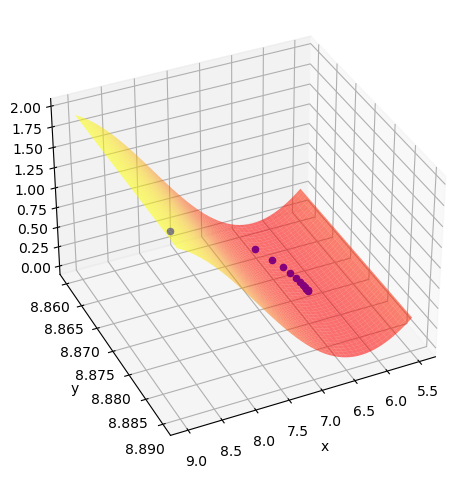

In [118]:
x = np.linspace(5.5,9) 
y = np.linspace(8.86,8.89)
 
# Create all pairs (x,y)
X, Y = np.meshgrid(x,y)  
 
# Function returns 2D array of z values for the pairs (x,y) 
def zfunc(x,y):  
    #print(x,y)
    return ((x**2)/4000) + ((y**2)/4000) - ((np.cos(x))*(np.cos(y/np.sqrt(2)))) + 1

# Set up plot and axes
fig = plt.figure(tight_layout=True)
ax = fig.add_subplot(projection='3d')  

# Plotting surface and labelling axes
ax.plot_surface(X,Y,zfunc(X,Y), alpha = 0.55, cmap ='autumn') 
ax.set_xlabel('x') 
ax.set_ylabel('y') 

#print(np_x_coords)
#print(np_y_coords)

for i in range(12):
    ax.scatter(float(np_x_coords[i]), float(np_y_coords[i]), zfunc(float(np_x_coords[i]), float(np_y_coords[i])), color = "b", marker = "o")

    #print(zfunc(float(np_x_coords[i]), float(np_y_coords[i])))    

ax.view_init(35, 65) # Change angle which plot is viewed at to make it easier to see target points

plt.show()

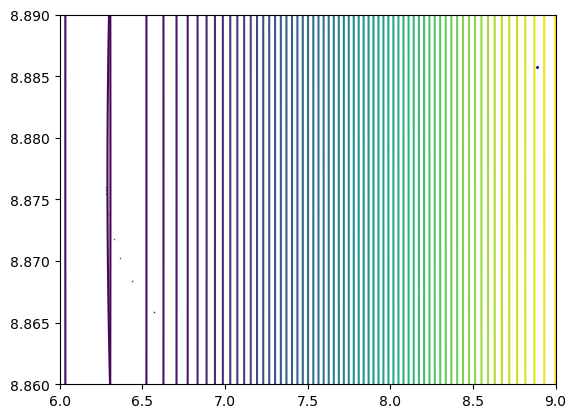

In [116]:
x = np.linspace(6,9) 
y = np.linspace(8.86,8.89)
 
# Create all pairs (x,y)
X, Y = np.meshgrid(x,y)  

fig, ax = plt.subplots()

for i in range(12):
    ax.scatter(float(np_x_coords[i]), float(np_y_coords[i]), zfunc(float(np_x_coords[i]), float(np_y_coords[i])), color = "b", marker = "x")

CS = ax.contour(X, Y, zfunc(X, Y), 75)

Checking correct formulae:

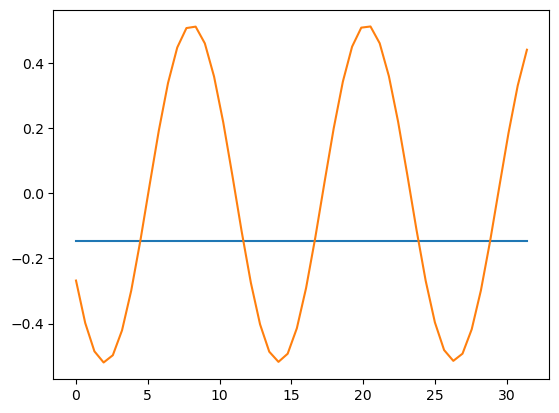

In [3]:
alpha = np.linspace(0, 10 * np.pi, 50)

y = np.ones(50)
for i in range(50):
    y[i] =(N(lhs.subs(a,2 * np.sqrt(2) * np.pi).subs(b,2 * np.sqrt(2) * np.pi).subs(g, alpha[i])))
    
plt.plot(alpha, N(rhs.subs(a,2 * np.sqrt(2) * np.pi).subs(b,2 * np.sqrt(2) * np.pi))*np.ones(50))    
plt.plot(alpha, y)